In [97]:
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [98]:
filenames_TGP = [f for f in glob.glob("*.txt") if f.startswith("scenario_srbench_TGP")]
filenames_CGP = [f for f in glob.glob("*.txt") if f.startswith("scenario_srbench_CGP")]

In [99]:
results_TGP={}
for f in filenames_TGP:
    with open(f,'r') as opf:
        reading=False
        datatset = ''
        train=0
        test=0
        for l in opf:
            if not reading:
                if l.startswith("Running dataset:"):
                    dataset=l[l.index(':')+2:].strip()
                    if dataset not in results_TGP.keys():
                        results_TGP[dataset]=[]
                    reading=True
            else:
                if l.startswith('==='):
                    results_TGP[dataset].append((train,test))
                    reading=False
                else:
                    line=l.split(' ')
                    if len(line)>3 and line[2] == 'score:':
                        if line[-1].strip().endswith("inf"):
                            print(f"infinity : {line}")
                            reading=False
                        elif line[1]=='train':
                            train=float(line[-1])
                        elif line[1]=='test':
                            test=float(line[-1])
                            
results_CGP={}
for f in filenames_CGP:
    with open(f,'r') as opf:
        reading=False
        datatset = ''
        train=0
        test=0
        for l in opf:
            if not reading:
                if l.startswith("Running dataset:"):
                    dataset=l[l.index(':')+2:].strip()
                    if dataset not in results_CGP.keys():
                        results_CGP[dataset]=[]
                    reading=True
            else:
                if l.startswith('==='):
                    results_CGP[dataset].append((train,test))
                    reading=False
                else:
                    line=l.split(' ')
                    if len(line)>3 and line[2] == 'score:':
                        if line[-1].strip().endswith("inf"):
                            print(f"infinity : {line}")
                            reading=False
                        elif line[1]=='train':
                            train=float(line[-1])
                        elif line[1]=='test':
                            test=float(line[-1])

print(results_CGP)

{'522_pm10': [(-8569755.398904134, -9887431.726442462), (-688930760.4585737, -593282159.7669827), (-144704990475137.97, -124366886523600.72), (-19.236725685230603, -19.19313683402416), (-436217.35757959425, -433397.10035271704), (-9.222515828780589, -7.772825002094082), (-417172516488.64374, -444362324040.0262), (-33235062.068336505, -37344166.48066415), (-19.864087523623514, -17.65543090329867), (-12635356.330925945, -12297448.669015657)], '678_visualizing_environmental': [(-8501.333785973682, -8052.259489904003), (-217.78552835433376, -122.62545936272788), (-127.68684113893056, -337.7819959781344), (-152.6790676661211, -184.66200644254383), (-4122253.1395103135, -3803011.7396735563), (-126.46772594968759, -102.73645744094252), (-555.1737904857861, -336.58658864628984), (-161.012371340034, -150.09843830599235), (-129.05030028833434, -115.3921703463948), (-85.44192300426006, -76.31894135330703)], '192_vineyard': [(-53.91948926598915, -20.968434122563135), (-14.229955584984147, -44.6572

In [100]:
# Prepare data for seaborn
data = []
for dataset, scores in results_TGP.items():
    seed=0
    for train_score, test_score in scores:
        data.append({'Algo':'TGP', 'Dataset': dataset, 'Seed': seed, 'Train': train_score, 'Test': test_score})
        seed=seed+1
for dataset, scores in results_CGP.items():
    seed=0
    for train_score, test_score in scores:
        data.append({'Algo':'CGP', 'Dataset': dataset, 'Seed': seed, 'Train': train_score, 'Test': test_score})
        seed=seed+1
df = pd.DataFrame(data)

df

,Algo,Dataset,Seed,Train,Test
0,TGP,522_pm10,0,1.420753e-01,1.306334e-01
1,TGP,522_pm10,1,1.702856e-01,2.506986e-02
2,TGP,522_pm10,2,1.228746e-03,7.754242e-02
3,TGP,522_pm10,3,1.683167e-01,1.484160e-01
4,TGP,522_pm10,4,-8.437521e-03,-1.052214e-01
5,TGP,522_pm10,5,8.639763e-02,1.247725e-01
6,TGP,522_pm10,6,-6.346709e-03,-3.978680e-02
7,TGP,522_pm10,7,9.623775e-02,9.504220e-02
8,TGP,522_pm10,8,-1.000221e-02,-6.020072e-02
9,TGP,522_pm10,9,3.017122e-02,3.687984e-02


In [101]:
def normalize_row(row):
    d=row.Dataset
    min_val = min(df[df["Dataset"]==d]["Train"].min(),df[df["Dataset"]==d]["Test"].min())
    max_val = max(df[df["Dataset"]==d]["Train"].max(),df[df["Dataset"]==d]["Test"].max())
    print(f'{d} : {min_val} -- {max_val}')
    row.Test = (row.Test - min_val) / (max_val - min_val)
    row.Train = (row.Train - min_val) / (max_val - min_val)
    
    return row

df_norm = df.apply(lambda x: normalize_row(x), axis=1)


522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
522_pm10 : -144704990475137.97 -- 0.17028562644755074
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visualizing_environmental : -4122253.1395103135 -- 0.28177335724996977
678_visual

In [102]:
df

,Algo,Dataset,Seed,Train,Test
0,TGP,522_pm10,0,1.420753e-01,1.306334e-01
1,TGP,522_pm10,1,1.702856e-01,2.506986e-02
2,TGP,522_pm10,2,1.228746e-03,7.754242e-02
3,TGP,522_pm10,3,1.683167e-01,1.484160e-01
4,TGP,522_pm10,4,-8.437521e-03,-1.052214e-01
5,TGP,522_pm10,5,8.639763e-02,1.247725e-01
6,TGP,522_pm10,6,-6.346709e-03,-3.978680e-02
7,TGP,522_pm10,7,9.623775e-02,9.504220e-02
8,TGP,522_pm10,8,-1.000221e-02,-6.020072e-02
9,TGP,522_pm10,9,3.017122e-02,3.687984e-02


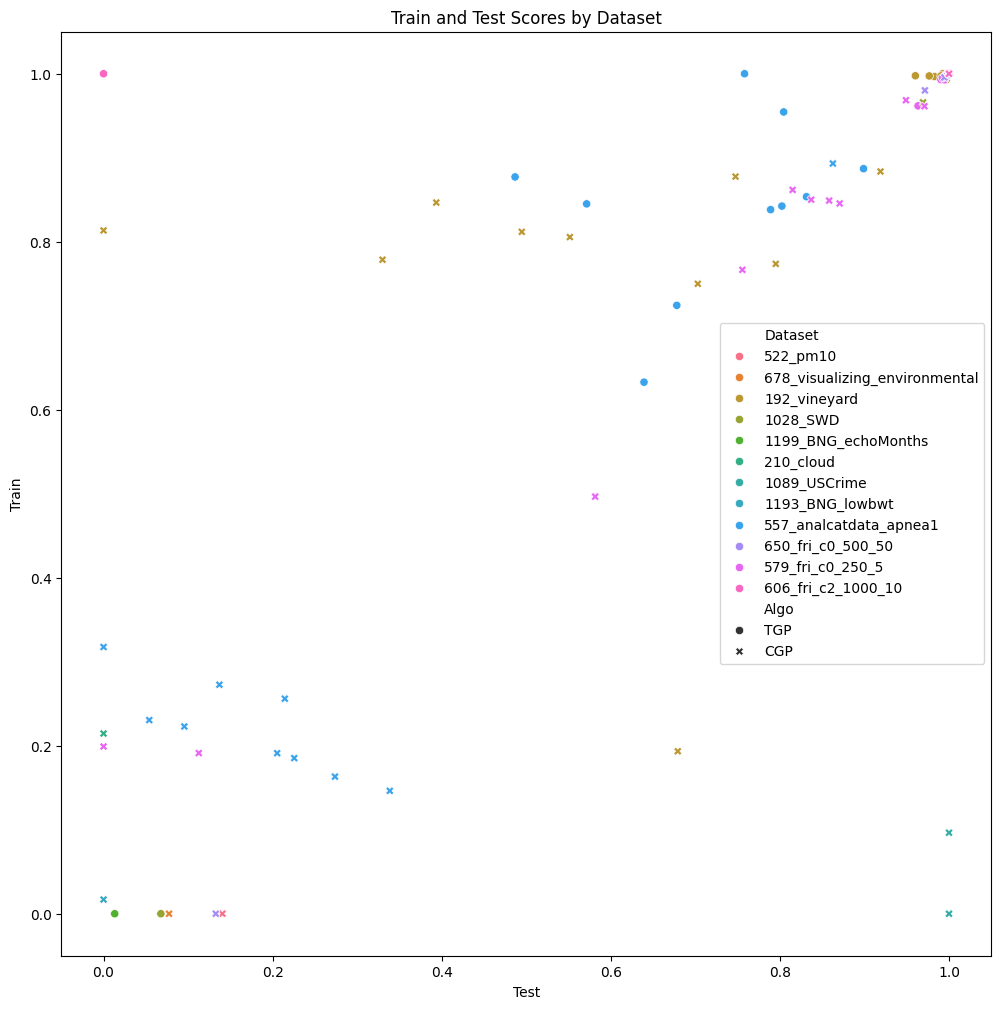

In [103]:
# Create the violin plot
plt.figure(figsize=(12, 12))
sns.scatterplot(x='Test', y='Train', hue='Dataset', style='Algo', data=df_norm)
# Add titles and labels
plt.title('Train and Test Scores by Dataset')
plt.xlabel('Test')
plt.ylabel('Train')

# Show the plot
plt.show()